## section 1. load and explore data

In [1]:
# 1. import libraries
import pandas as pd
import numpy as np

In [2]:
# 2. load the csv file
df = pd.read_csv('Ecommerce_Orders_Data.csv')

In [3]:
df.head(10)

,OrderID,CustomerName,CustomerEmail,Country,Category,Product,UnitPrice,Quantity,Discount,OrderDate,DeliveryDate,DeliveryDays,PaymentMethod,OrderStatus,Rating
0,ORD10000,James Kamau,james.kamau@email.com,Nigeria,Books,Self Help Guide,104.04,3.0,0.00,2024-09-11,2024-09-17,6.0,credit card,Processing,NaN
1,ORD10001,Emmanuel Owusu,emmanuel.owusu@email.com,Nigeria,Toys,Puzzle,412.05,4.0,0.00,2025-04-17,2025-04-24,7.0,Bank Transfer,Processing,NaN
2,ORD10002,Efua Njeri,efua.njeri@email.com,Ghana,Clothing,Hoodie,494.84,9.0,0.00,2025-04-18,2025-05-06,18.0,PayPal,Shipped,4.0
3,ORD10003,Akua Owusu,akua.owusu@email.com,Uganda,Beauty,Shampoo,472.24,3.0,0.00,2024-04-22,2024-04-24,2.0,MOBILE MONEY,Delivered,NaN
4,ORD10004,Samuel Okonkwo,samuel.okonkwo@email.com,Tanzania,Beauty,Sunscreen,104.39,1.0,0.15,2024-08-04,2024-08-20,16.0,Credit Card,Shipped,NaN
5,ORD10005,Fatima Okonkwo,fatima.okonkwo@email.com,Uganda,Beauty,Shampoo,305.98,7.0,0.00,2024-04-08,NaN,NaN,MOBILE MONEY,Cancelled,NaN
6,ORD10006,Kwesi Mensah,kwesi.mensah@email.com,Tanzania,Clothing,Hoodie,63.02,6.0,0.00,2024-03-15,2024-04-02,18.0,credit card,Returned,3.0
7,ORD10007,Grace Mohamed,grace.mohamed@email.com,Nigeria,Beauty,Face Cream,94.71,1.0,0.00,2025-02-12,2025-02-28,16.0,Mobile Money,Shipped,4.0
8,ORD10008,Emmanuel Njeri,emmanuel.njeri@email.com,Kenya,Toys,Lego Set,441.85,7.0,0.00,2024-03-12,2024-03-30,18.0,Bank Transfer,Returned,NaN
9,ORD10009,David Diallo,david.diallo@email.com,Ghana,Beauty,Shampoo,144.73,10.0,0.20,2025-03-26,2025-04-03,8.0,Mobile Money,Shipped,3.0


In [4]:
print("shape of dataset:",df.shape)

shape of dataset: (618, 15)


In [5]:
# column info and data types
print("\ncolumn info:")
df.info()


column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        618 non-null    object 
 1   CustomerName   618 non-null    object 
 2   CustomerEmail  594 non-null    object 
 3   Country        600 non-null    object 
 4   Category       618 non-null    object 
 5   Product        618 non-null    object 
 6   UnitPrice      600 non-null    float64
 7   Quantity       584 non-null    float64
 8   Discount       588 non-null    float64
 9   OrderDate      618 non-null    object 
 10  DeliveryDate   517 non-null    object 
 11  DeliveryDays   517 non-null    float64
 12  PaymentMethod  618 non-null    object 
 13  OrderStatus    618 non-null    object 
 14  Rating         367 non-null    float64
dtypes: float64(5), object(10)
memory usage: 72.6+ KB


In [6]:
# statistical summary of numeric columns
df.describe()

,UnitPrice,Quantity,Discount,DeliveryDays,Rating
count,600.000000,584.000000,588.000000,517.000000,367.000000
mean,253.524350,5.400685,0.073980,10.901354,3.089918
std,145.506088,2.838790,0.076685,5.542991,1.404552
min,5.060000,1.000000,0.000000,2.000000,1.000000
25%,124.635000,3.000000,0.000000,6.000000,2.000000
50%,262.015000,5.000000,0.050000,11.000000,3.000000
75%,380.117500,8.000000,0.150000,16.000000,4.000000
max,499.840000,10.000000,0.200000,20.000000,5.000000


In [7]:
# unique values per column
print("\nunique values per column:")
df.nunique()


unique values per column:


OrderID          600
CustomerName     189
CustomerEmail    188
Country            8
Category          14
Product           35
UnitPrice        577
Quantity          10
Discount           5
OrderDate        354
DeliveryDate     334
DeliveryDays      19
PaymentMethod      6
OrderStatus        5
Rating             5
dtype: int64

In [8]:
# unique values in category-look for 'electronics' vs 'Electronics'
print("\nunique Categories:", df['Category'].unique())


unique Categories: ['Books' 'Toys' 'Clothing' 'Beauty' 'sports' 'books' 'Sports'
 'Electronics' 'electronics' 'Home & Kitchen' 'toys' 'clothing'
 'home & kitchen' 'beauty']


In [9]:
# unique payment methods
print("\nunique Payment Method:", df['PaymentMethod'].unique())


unique Payment Method: ['credit card' 'Bank Transfer' 'PayPal' 'MOBILE MONEY' 'Credit Card'
 'Mobile Money']


## section 2. Handle missing values

In [10]:
# missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
OrderID            0
CustomerName       0
CustomerEmail     24
Country           18
Category           0
Product            0
UnitPrice         18
Quantity          34
Discount          30
OrderDate          0
DeliveryDate     101
DeliveryDays     101
PaymentMethod      0
OrderStatus        0
Rating           251
dtype: int64


In [11]:
# standardise text column to title case
# this will fix 'book'->'Books','MOBILE MONEY'->'Mobile Money'
text_columns = ['Category','PaymentMethod','Country','OrderStatus','Product']
for col in text_columns:
    df[col] = df[col].str.title()

In [12]:
print("\nunique Categories after cleaning:", df['Category'].unique())
print("\nunique Payment Methods after cleaning:", df['PaymentMethod'].unique())


unique Categories after cleaning: ['Books' 'Toys' 'Clothing' 'Beauty' 'Sports' 'Electronics'
 'Home & Kitchen']

unique Payment Methods after cleaning: ['Credit Card' 'Bank Transfer' 'Paypal' 'Mobile Money']


In [13]:
# handle missing DeliveryDate and DeliveryDays
# Option: fill missing DeliveryDays with the average
avg_delivery = df['DeliveryDays'].mean()
df['DeliveryDays'].fillna(avg_delivery,inplace=True)

C:\Users\user 1\AppData\Local\Temp\ipykernel_11180\1306493119.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DeliveryDays'].fillna(avg_delivery,inplace=True)


In [14]:
df = df.dropna(subset=['DeliveryDate']) # CORRECT: - no S

In [15]:
# calculate the percentage of the missing values
print("\nPercentage of missing values:")
print(df.isnull().mean()*100)


Percentage of missing values:
OrderID           0.000000
CustomerName      0.000000
CustomerEmail     4.061896
Country           3.094778
Category          0.000000
Product           0.000000
UnitPrice         3.094778
Quantity          5.802708
Discount          5.222437
OrderDate         0.000000
DeliveryDate      0.000000
DeliveryDays      0.000000
PaymentMethod     0.000000
OrderStatus       0.000000
Rating           39.458414
dtype: float64


In [16]:
# fill UnitPrice and Quantity with median
df.loc[:,'UnitPrice'] = df['UnitPrice'].fillna(df['UnitPrice'].median())
df.loc[:,'Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [17]:
# fill discount with 0- assume no discount was applied
df.loc[:,'Discount'] = df['Discount'].fillna(0)

In [18]:
# fill country and customeremail with unknown
df.loc[:,'Country'] = df['Country'].fillna('Unknown')
df.loc[:,'CustomerEmail'] = df['CustomerEmail'].fillna('Unknown')

# comments for rating and delivery
# comment: Ratings are missing because the customers did not leave a review
# comment: DeliveryDate and DeliveryDays are missing because the order has not been delivered yet.

In [19]:
print("\nMissing values after cleaning;")
print(df.isnull().sum())


Missing values after cleaning;
OrderID            0
CustomerName       0
CustomerEmail      0
Country            0
Category           0
Product            0
UnitPrice          0
Quantity           0
Discount           0
OrderDate          0
DeliveryDate       0
DeliveryDays       0
PaymentMethod      0
OrderStatus        0
Rating           204
dtype: int64


In [20]:
# comment: those 204 rating missing are those customers who did not leave a review and we left them on purpose

## Section 3- fix incosistent text

In [21]:
# fix category column
df.loc[:,'Category'] = df['Category'].str.title()

In [22]:
# fix PaymentMethod column
df.loc[:,'PaymentMethod'] = df['PaymentMethod'].str.title()

In [23]:
# verify
print("Unique Category after cleaning:")
print(df['Category'].unique())
print("\nUnique Payment Methods after cleaning:")
print(df['PaymentMethod'].unique())

Unique Category after cleaning:
['Books' 'Toys' 'Clothing' 'Beauty' 'Sports' 'Electronics'
 'Home & Kitchen']

Unique Payment Methods after cleaning:
['Credit Card' 'Bank Transfer' 'Paypal' 'Mobile Money']


## Section 4. remove duplicates

In [24]:
# how many duplicates rows exist
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 15


In [25]:
# show a few duplicate rows
print("\nSample duplicate rows:")
print(df[df.duplicated()].head())


Sample duplicate rows:
      OrderID    CustomerName             CustomerEmail       Country  \
601  ORD10155    Samuel Smith    samuel.smith@email.com        Uganda   
602  ORD10040  Emmanuel Kamau  emmanuel.kamau@email.com  South Africa   
603  ORD10212     Linda Kamau     linda.kamau@email.com      Tanzania   
604  ORD10052  Fatima Boateng  fatima.boateng@email.com         Kenya   
606  ORD10111     Grace Kamau     grace.kamau@email.com      Tanzania   

           Category                Product  UnitPrice  Quantity  Discount  \
601     Electronics      Bluetooth Speaker     486.06       5.0      0.20   
602  Home & Kitchen              Air Fryer      90.63       5.0      0.15   
603     Electronics       Wireless Earbuds     184.18       1.0      0.15   
604  Home & Kitchen              Knife Set     172.92       1.0      0.00   
606           Books  Data Science Handbook      32.26       3.0      0.05   

      OrderDate DeliveryDate  DeliveryDays PaymentMethod OrderStatus  Rati

In [26]:
# remove duplicates, keep first
df = df.drop_duplicates()

In [27]:
# reset the index after the dropping
df = df.reset_index(drop=True)

In [28]:
# verify the duplicates are gone
print(f"Number of duplicate rows after cleaning: {df.duplicated().sum()}")
print(f"\nNew shape of dataset: {df.shape}")

Number of duplicate rows after cleaning: 0

New shape of dataset: (502, 15)


## section 5. fix data types and create new columns

In [29]:
# convert OrderDate and DeliveryDate to proper datetime format
df['Orderdate'] = pd.to_datetime(df['OrderDate'])
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])

print("Converted! check data types:")
print(df[['OrderDate','DeliveryDate']].dtypes)

Converted! check data types:
OrderDate               object
DeliveryDate    datetime64[ns]
dtype: object


In [30]:
# create new column: TotalRevenue
# Formula: UnitPrice * Quantity * (1-Discount)
df['TotalRevenue'] = df['UnitPrice'] * df['Quantity'] * (1-df['Discount'])

In [31]:
df['TotalRevenue']

0       312.1200
1      1648.2000
2      4453.5600
3      1416.7200
4        88.7315
         ...    
497     990.1600
498     393.7800
499     178.3800
500    2318.5440
501    1284.0950
Name: TotalRevenue, Length: 502, dtype: float64

In [32]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

print("Check again:")
print(df[['OrderDate','DeliveryDate']].dtypes)

Check again:
OrderDate       datetime64[ns]
DeliveryDate    datetime64[ns]
dtype: object


In [33]:
# create new column: OrderDate - extract month name from OrderDate
df['OrderMonth'] = df['OrderDate'].dt.month_name()

In [34]:
# create a new column: OrderYear - exract month name from orderdate
df['OrderYear'] = df['OrderDate'].dt.year

In [35]:
# verify new columns and data types
print("\nData types of all columns:")
print(df.dtypes)
print(f"nNew shape of dataset: {df.shape}")
print("\nFirst 5 rows with new columns:")
print(df[['OrderDate','DeliveryDate','TotalRevenue','OrderMonth','OrderYear']].head())


Data types of all columns:
OrderID                  object
CustomerName             object
CustomerEmail            object
Country                  object
Category                 object
Product                  object
UnitPrice               float64
Quantity                float64
Discount                float64
OrderDate        datetime64[ns]
DeliveryDate     datetime64[ns]
DeliveryDays            float64
PaymentMethod            object
OrderStatus              object
Rating                  float64
Orderdate        datetime64[ns]
TotalRevenue            float64
OrderMonth               object
OrderYear                 int32
dtype: object
nNew shape of dataset: (502, 19)

First 5 rows with new columns:
   OrderDate DeliveryDate  TotalRevenue OrderMonth  OrderYear
0 2024-09-11   2024-09-17      312.1200  September       2024
1 2025-04-17   2025-04-24     1648.2000      April       2025
2 2025-04-18   2025-05-06     4453.5600      April       2025
3 2024-04-22   2024-04-24     1416.72

## Section 6. Analysis Questions

In [36]:
# 1. Total Revenue
print("Total Revenue:", df['TotalRevenue'].sum())

Total Revenue: 637266.2435


In [37]:
# country with the highest Total Revenue
print("Top Country by Revenue:", df.groupby('Country')['TotalRevenue'].sum().idxmax())

Top Country by Revenue: South Africa


In [38]:
# 3. top category by orders
print("Top Category by Orders:", df['Category'].value_counts().idxmax())

Top Category by Orders: Clothing


In [39]:
# 4. Average Delivery Days
# i do not have DeliveryDays column yet, I need to create it first:
df['DeliveryDays'] = (df['DeliveryDate'] - df['OrderDate']).dt.days
print("Avg Delivery Days:", df['DeliveryDays'].mean())

Avg Delivery Days: 10.864541832669323


In [40]:
# 5. %  Cancelled or returned
cancelled = df[df['OrderStatus'].isin(['Cancelled','Returned'])].shape[0]
print("Cancelled/Returned %:", round(cancelled/len(df)*100, 2), "%")
    

Cancelled/Returned %: 37.45 %


In [41]:
# 6. most used PaymentMethod
print("Most used Payment Method:", df['PaymentMethod'].value_counts().idxmax())

Most used Payment Method: Mobile Money


In [42]:
# 7. Highest rated Category
print("Highest Rated Category:", df.groupby('Category')['Rating'].mean().idxmax())

Highest Rated Category: Electronics


In [43]:
#.8 Month with Highest Revenue
print("Best Month for Revenue:", df.groupby('OrderMonth')['TotalRevenue'].sum().idxmax())

Best Month for Revenue: May


In [44]:
# 9. Top 5 countries by Revenue
print("\nTop 5 Countries:", df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head())


Top 5 Countries: Country
South Africa    108561.4275
Nigeria          81940.9680
Kenya            76613.2780
Senegal          74773.3555
Uganda           72083.9355
Name: TotalRevenue, dtype: float64


In [45]:
# 10. Top 5 Products by Quantity
print("\nTop 5 Product by Quantity:\n", df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head())


Top 5 Product by Quantity:
 Product
Novel                    115.0
Wireless Earbuds         105.0
Laptop Stand             103.0
Data Science Handbook    102.0
Running Shoes             99.0
Name: Quantity, dtype: float64


In [46]:
# 11. Average Discount
print("Avg Discount:", round(df['Discount'].mean()*100, 2), "%")

Avg Discount: 6.81 %


In [47]:
# 12. Orders per OrderStatus
print("\nOrders by status:\n", df['OrderStatus'].value_counts())


Orders by status:
 OrderStatus
Delivered     113
Shipped       105
Cancelled     103
Processing     96
Returned       85
Name: count, dtype: int64


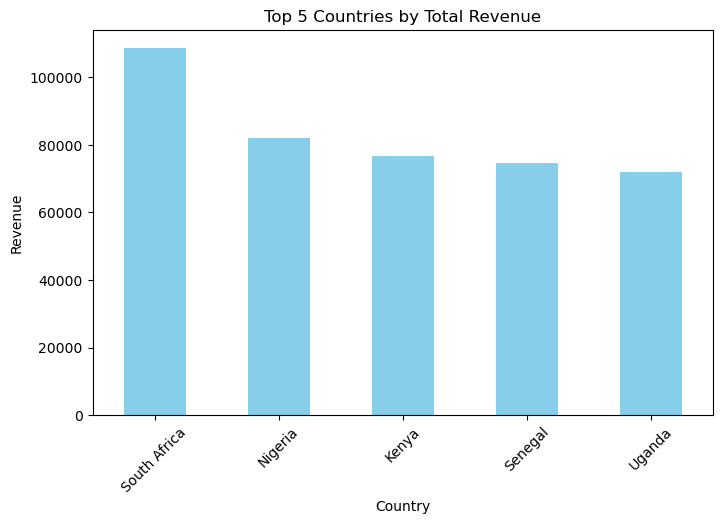

In [48]:
# Chart 1: Bar chart - Revenue by Country
import matplotlib.pyplot as plt

# Top 5 Countries by Revenue
top_countries = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head()

plt.figure(figsize=(8,5))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 5 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


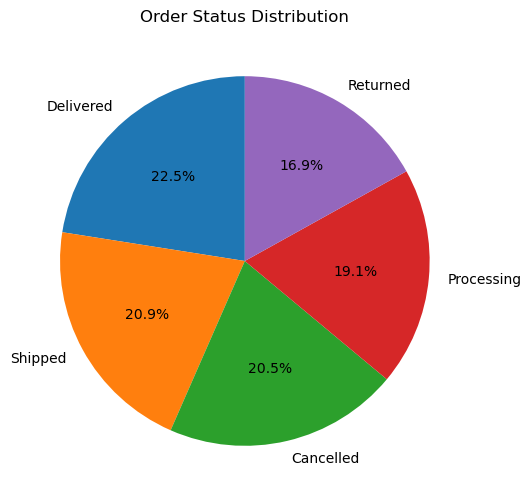

In [49]:
# Chart 2. Pie Chart - Order Status Distribution
# Orders by Status
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(6,6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Order Status Distribution')
plt.ylabel('') # hides the ylabel
plt.show()


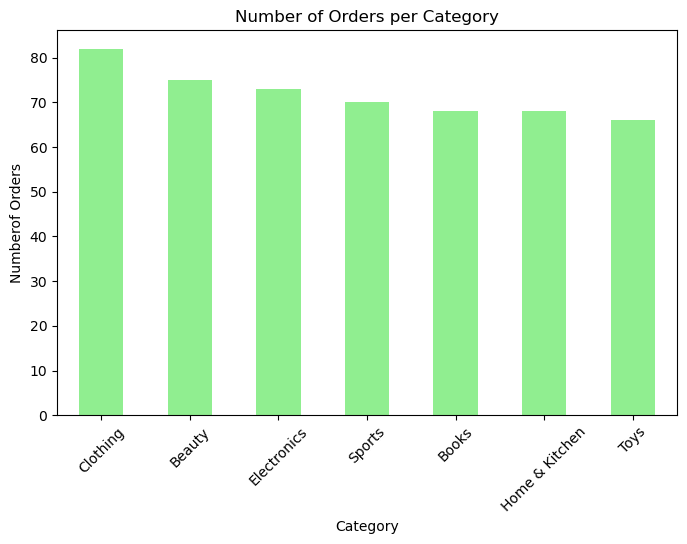

In [50]:
# Chart 3. Bar chart - Number of Orders per Category
category_counts = df['Category'].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind='bar', color='lightgreen')
plt.title('Number of Orders per Category')
plt.xlabel('Category')
plt.ylabel('Numberof Orders')
plt.xticks(rotation=45)
plt.show()

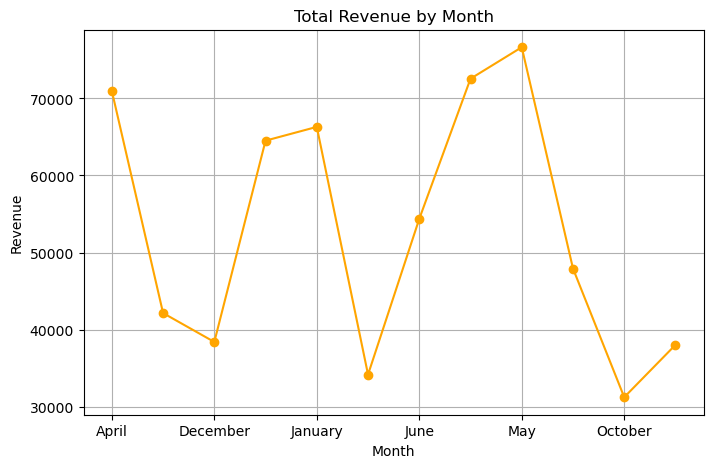

In [51]:
# Chart 4. Line Chart - Revenue by month
monthly_revenue = df.groupby('OrderMonth')['TotalRevenue'].sum()

plt.figure(figsize=(8,5))
monthly_revenue.plot(kind='line', marker='o', color='orange')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

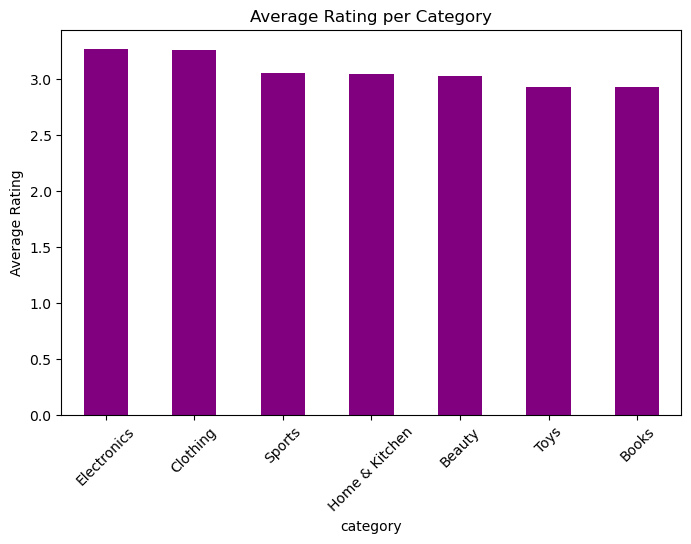

In [52]:
# Chart 5. Bar Chart - Average Rating per Category
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
avg_rating.plot(kind='bar', color='purple')
plt.title('Average Rating per Category')
plt.xlabel('category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

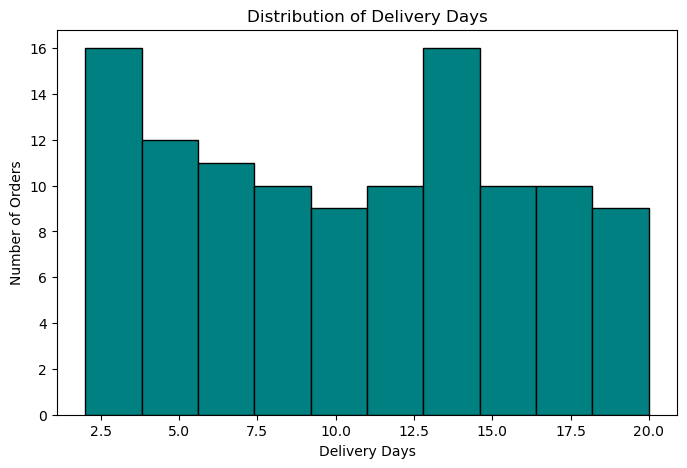

In [53]:
# chart 6. Histogram - Distribution of DeliveryDays
# Only for delivered orders
delivered = df[df['OrderStatus'] == 'Delivered']

plt.figure(figsize=(8,5))
delivered['DeliveryDays'].plot(kind='hist', bins=10, color='teal', edgecolor='black')
plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.show()

In [54]:
df.to_csv('ecommerce_data.csv', index=False)